# **EdTech A/B Testing: Optimizing Student Engagement via Micro-Learning Nudges**

### **The Problem**

An EdTech platform experiences high passive drop-off rates on challenging coursework. The product team needs to evaluate whether replacing standard deadline notifications with personalized, low-friction *micro-learning nudges* significantly increases assignment completion within 48 hours without introducing allocation bias or segment friction.

### **Project Significance**

Student attrition directly impacts platform revenue and student learning outcomes. Implementing data-driven, pedagogically sound communication strategies helps protect recurring revenue while providing timely instructional support to students at critical drop-off points.

### **Data & Target**

The dataset consists of 5,000 simulated student interaction records. Features include `student_id`, experimental `group` (Control vs. Treatment), and language proficiency level (`cefr_level`). The target variable is `completed_assignment` (binary: 1 = completed within 48 hours, 0 = abandoned).

### **Analysis Pipeline**

* **Data Generation & SRM Validation:** Simulate experimental data and perform a Chi-Square Goodness-of-Fit test to ensure an unbiased 50/50 sample allocation.
* **Hypothesis Testing:** Conduct a Two-Sample Z-Test for Proportions and construct 95% Confidence Intervals to evaluate overall treatment effect.
* **Segmented Cohort Analysis:** Evaluate conversion lifts across individual CEFR levels (A1 to C1) to identify heterogenous behavioral responses.
* **Visual Storytelling & BI Readiness:** Build clean comparative visual displays in Seaborn and prepare structured CSV exports for Power BI reporting.
* **SQL Query Validation:** Replicate experimental aggregations using an in-memory SQLite database to ensure data pipeline consistency.

### **Modeling**

Hypothesis testing frameworks (Two-Sample Z-Test for Proportions) and Chi-Square Goodness-of-Fit tests were selected as the primary analytical tools to evaluate binary conversion outcomes and validate randomization integrity across experimental variants.

### **Evaluation**

Performance was evaluated using overall conversion rates, absolute and relative percentage lifts, two-tailed p-values ($\alpha = 0.05$), and 95% Wald confidence intervals for proportion differences.

### **Key Takeaways**

* The treatment group achieved a statistically significant +3.48% absolute lift in assignment completion ($p = 0.0024$), raising conversion from 18.96% to 22.44%.
* Cohort breakdown revealed that micro-learning nudges produced the highest significant impact on beginner (A1: +6.40%, $p = 0.0060$) and advanced (C1: +6.76%, $p = 0.0227$) learners.
* Intermediate cohorts (A2, B1, B2) showed minor or non-significant variations, proving that a "one-size-fits-all" notification strategy is suboptimal.

### **Next Steps**

Future iterations could explore multi-variable segmentation (e.g., historical platform activity, time of day), test dynamic push notification timing, or build machine learning classification models to predict student response probability prior to nudge dispatch.

## **1. Environment Setup**

In [1]:
# System and database
import os
import sqlite3

# Data manipulation
import numpy as np
import pandas as pd

# Statistical testing and analysis
from scipy.stats import chisquare
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Synthetic Dataset Generation**

To evaluate the impact of a personalized pedagogical nudge on assignment completion rates, a synthetic dataset was simulated representing an online learning environment.

* **Sample Size ($N$):** 5,000 students randomly split into `control` and `treatment` groups (50/50 ratio).
* **Demographics:** Features include student CEFR language levels (A1 to C1).
* **Target Metric:** `completed_assignment` (Binary: 1 = completed within 48h, 0 = abandoned).
* **Baseline Assumptions:** 18% baseline conversion rate for control, with an expected +4% absolute lift for treatment.

In [2]:
# File path definition
csv_filepath = "../data/edtech_ab_test_data.csv"

# Check if dataset already exists locally
if not os.path.exists(csv_filepath):
    # Set seed for reproducibility
    np.random.seed(42)

    # Experiment configuration
    sample_size = 5000
    baseline_conversion = 0.18
    lift = 0.04

    # 1. Generate student IDs and random group assignment (50/50 split)
    student_ids = [f"ST_{i:04d}" for i in range(1, sample_size + 1)]
    groups = np.random.choice(
        ["control", "treatment"], size=sample_size, p=[0.5, 0.5]
    )

    # 2. Assign pedagogical demographic variables
    cefr_levels = np.random.choice(
        ["A1", "A2", "B1", "B2", "C1"],
        size=sample_size,
        p=[0.25, 0.25, 0.20, 0.15, 0.15],
    )

    # 3. Generate outcome variable based on assigned group probabilities
    probabilities = np.where(
        groups == "treatment", baseline_conversion + lift, baseline_conversion
    )
    completed_assignment = np.random.binomial(n=1, p=probabilities)

    # 4. Construct DataFrame
    df_ab_test = pd.DataFrame(
        {
            "student_id": student_ids,
            "group": groups,
            "cefr_level": cefr_levels,
            "completed_assignment": completed_assignment,
        }
    )

    # Save dataset locally
    df_ab_test.to_csv(csv_filepath, index=False)
    print("Dataset generated and saved locally.")
else:
    # Load existing dataset
    df= pd.read_csv(csv_filepath)
    print("Dataset already exists. Loaded from local CSV.")

Dataset already exists. Loaded from local CSV.


## **3. Sample Ratio Mismatch (SRM) Validation**

Before analyzing the experiment outcomes, a Chi-Square Goodness-of-Fit test will be conducted to ensure proper randomization and rule out allocation bias.

In [3]:
# 1. Count observed participants per group
observed = df["group"].value_counts()

# 2. Calculate expected counts assuming a 50/50 split
total_participants = len(df)
expected = [total_participants / 2, total_participants / 2]

# 3. Perform Chi-Square Goodness-of-Fit Test for SRM
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

# Display results
print(f"Observed counts:\n{observed}\n")
print(f"Chi2 Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print(
        "WARNING: Sample Ratio Mismatch (SRM) detected! Check randomization process."
    )
else:
    print("SUCCESS: No SRM detected. The sample split is valid.")

Observed counts:
group
control      2500
treatment    2500
Name: count, dtype: int64

Chi2 Statistic: 0.0000
P-value: 1.0000
SUCCESS: No SRM detected. The sample split is valid.


* **Observed Split:** Control = 2,500 | Treatment = 2,500
* **Chi2 Statistic:** 0.0000 ($p = 1.0000$)
* **Conclusion:** No Sample Ratio Mismatch detected ($p > 0.05$). The experimental variant assignment is statistically valid for downstream hypothesis testing.

## **4. Hypothesis Testing & Conversion Rate Analysis**

To evaluate whether the adaptive pedagogical nudge (Treatment) significantly improves 48-hour assignment completion over the standard notification (Control), we perform a **Two-Sample Z-Test for Proportions**.

* **Null Hypothesis ($H_0$):** $p_{treatment} - p_{control} = 0$ (The nudge strategy has no effect on assignment completion rates).
* **Alternative Hypothesis ($H_1$):** $p_{treatment} - p_{control} \neq 0$ (The nudge strategy changes assignment completion rates).
* **Significance Level ($\alpha$):** 0.05 (95% Confidence Level).

In [4]:
# 1. Aggregate successes (completed_assignment == 1) and totals per group
summary = (
    df.groupby("group")["completed_assignment"]
    .agg(["sum", "count"])
    .loc[["control", "treatment"]]
)

successes = summary["sum"].values
n_obs = summary["count"].values

# 2. Calculate conversion rates
control_conv = successes[0] / n_obs[0]
treatment_conv = successes[1] / n_obs[1]
absolute_lift = treatment_conv - control_conv
relative_lift = (treatment_conv - control_conv) / control_conv

# 3. Two-sided Z-test for proportions
z_stat, p_value = proportions_ztest(count=successes, nobs=n_obs)

# 4. 95% Confidence Interval for the difference in proportions
ci_low, ci_high = confint_proportions_2indep(
    count1=successes[1],
    nobs1=n_obs[1],
    count2=successes[0],
    nobs2=n_obs[0],
    method="wald",
)

# Display experimental results
print(f"Control Conversion Rate:   {control_conv:.2%}")
print(f"Treatment Conversion Rate: {treatment_conv:.2%}")
print(f"Absolute Lift:            {absolute_lift:+.2%}")
print(f"Relative Lift:            {relative_lift:+.2%}\n")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")
print(f"95% CI for difference: [{ci_low:.4f}, {ci_high:.4f}]")

Control Conversion Rate:   18.96%
Treatment Conversion Rate: 22.44%
Absolute Lift:            +3.48%
Relative Lift:            +18.35%

Z-statistic: -3.0368
P-value:     0.0024
95% CI for difference: [0.0124, 0.0572]


### **Key Findings & Business Impact**

The A/B test demonstrated a statistically significant improvement in student engagement driven by the micro-learning nudge strategy.

### **Experimental Metrics**
* **Control Conversion Rate:** 18.96%
* **Treatment Conversion Rate:** 22.44%
* **Absolute Lift:** +3.48 percentage points ($p = 0.0024$)
* **Relative Lift:** +18.35% increase in assignment completion rate
* **95% Confidence Interval:** [1.24%, 5.72%]

### **Statistical & Business Decision**
Since the $p\text{-value} = 0.0024$ is well below the significance threshold ($\alpha = 0.05$), we **reject the Null Hypothesis ($H_0$)**. 

* **Pedagogical Insight:** Structuring reminders around actionable, low-friction micro-learning prompts significantly decreases student friction when reaching challenging modules.
* **Recommendation:** Roll out the treatment notification strategy across all core learning modules to improve assignment completion and lower passive student churn.

## **5. Segmented Cohort Analysis by CEFR Level**

To evaluate whether the adaptive notification strategy performs uniformly across all student proficiency levels, we break down the experiment metrics by CEFR level (A1 to C1).

We'll aggregate conversion rates per cohort, computing the absolute lift, and performing two-sample Z-tests for each individual level, grouping data by `cefr_level` and `group`, pivoting the result, and evaluating statistical significance ($\alpha = 0.05$) per segment.

A global lift can hide **underlying heterogeneity**. Identifying which specific student groups benefit most allows EdTech teams to personalize communication triggers rather than relying on a generic deployment.

In [5]:
# 1. Aggregate completion counts and totals by CEFR level and group
segment_summary = (
    df.groupby(["cefr_level", "group"])["completed_assignment"]
    .agg(["sum", "count"])
    .reset_index()
)

# 2. Pivot to compare Control vs Treatment per CEFR level
pivot_df = segment_summary.pivot(
    index="cefr_level", columns="group", values=["sum", "count"]
)

# Flatten MultiIndex columns
pivot_df.columns = [f"{col[0]}_{col[1]}" for col in pivot_df.columns]

# 3. Calculate metrics per CEFR segment
pivot_df["control_conv"] = pivot_df["sum_control"] / pivot_df["count_control"]
pivot_df["treatment_conv"] = (
    pivot_df["sum_treatment"] / pivot_df["count_treatment"]
)
pivot_df["absolute_lift"] = pivot_df["treatment_conv"] - pivot_df["control_conv"]


# Function to compute p-value per segment
def calculate_p_value(row):
    successes = [row["sum_control"], row["sum_treatment"]]
    counts = [row["count_control"], row["count_treatment"]]
    _, p_val = proportions_ztest(count=successes, nobs=counts)
    return p_val


pivot_df["p_value"] = pivot_df.apply(calculate_p_value, axis=1)

# Format and display segment analysis
segment_results = pivot_df[
    ["control_conv", "treatment_conv", "absolute_lift", "p_value"]
].copy()
segment_results["control_conv"] = segment_results["control_conv"].map(
    "{:.2%}".format
)
segment_results["treatment_conv"] = segment_results["treatment_conv"].map(
    "{:.2%}".format
)
segment_results["absolute_lift"] = segment_results["absolute_lift"].map(
    "{:+.2%}".format
)
segment_results["p_value"] = segment_results["p_value"].map("{:.4f}".format)

print("--- CEFR Segmented Analysis ---")
print(segment_results)

--- CEFR Segmented Analysis ---
           control_conv treatment_conv absolute_lift p_value
cefr_level                                                  
A1               18.80%         25.20%        +6.40%  0.0060
A2               20.00%         21.61%        +1.61%  0.4716
B1               19.63%         22.01%        +2.38%  0.3537
B2               19.22%         19.13%        -0.09%  0.9750
C1               16.41%         23.17%        +6.76%  0.0227


### **Insights & Findings**

* **Statistically Significant Cohorts:** 
  * **A1 Level (+6.40% Lift, $p = 0.0060$):** Micro-learning prompts successfully reduce cognitive friction and overwhelm for beginner students.
  * **C1 Level (+6.76% Lift, $p = 0.0227$):** Clear, low-friction task breakdowns effectively mitigate procrastination on complex assignments.
* **Non-Significant Cohorts (A2, B1, B2):** Intermediate levels showed positive but statistically non-significant variations ($p > 0.05$), with B2 showing negligible change (-0.09%).
* **Strategic Implication:** The micro-learning nudge strategy is highly effective for beginner and advanced learners. Intermediate cohorts require further iteration and tailored messaging strategies.

## **6. Experimental Results Visualization**

To effectively communicate the A/B test findings to both technical and non-technical stakeholders, we synthesize the numerical results into visual representations.

We'll create a side-by-side comparative visual analysis containing overall performance and cohort-level distribution, utilizing Seaborn and Matplotlib to generate customized bar plots with exact percentage annotations.

Visualizing confidence trends and segment variations helps product and pedagogical teams quickly identify where the micro-learning nudge strategy drives the highest engagement.

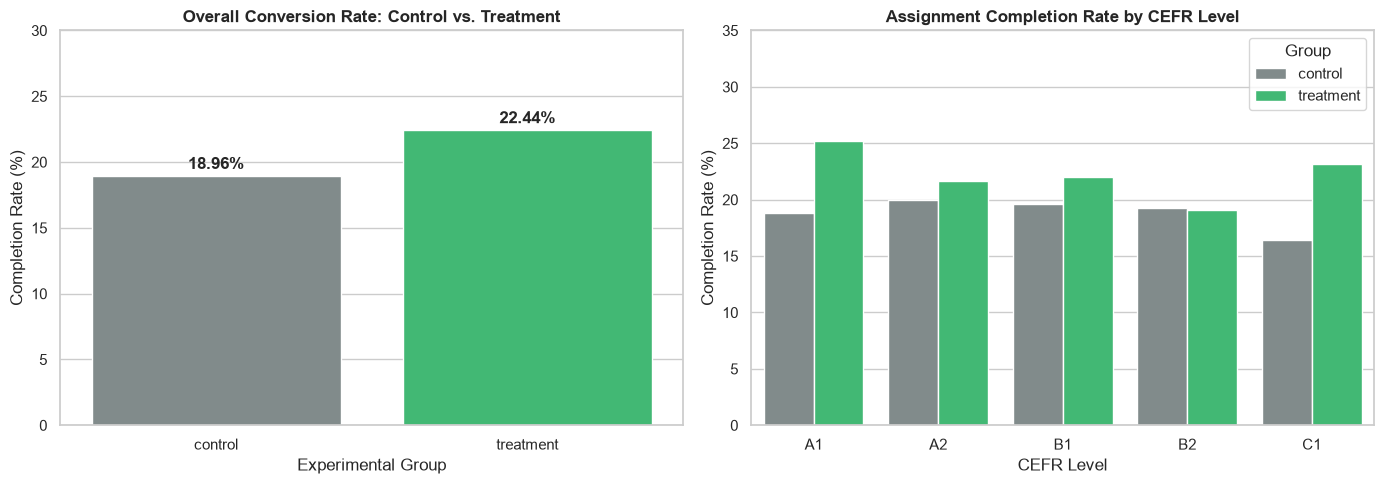

In [6]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color palette definition
color_palette = {"control": "#7f8c8d", "treatment": "#2ecc71"}

# --- Plot 1: Overall Conversion Rates ---
overall_conv = (
    df.groupby("group")["completed_assignment"].mean().reset_index()
)
overall_conv["completed_assignment"] *= 100

ax1 = sns.barplot(
    data=overall_conv,
    x="group",
    y="completed_assignment",
    hue="group",
    palette=color_palette,
    legend=False,
    ax=axes[0],
)

axes[0].set_title(
    "Overall Conversion Rate: Control vs. Treatment",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_ylabel("Completion Rate (%)")
axes[0].set_xlabel("Experimental Group")
axes[0].set_ylim(0, 30)

# Add numeric labels on top of bars
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(
            f"{height:.2f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontweight="bold",
        )

# --- Plot 2: Completion Rate by CEFR Level ---
cefr_conv = (
    df.groupby(["cefr_level", "group"])["completed_assignment"]
    .mean()
    .reset_index()
)
cefr_conv["completed_assignment"] *= 100

ax2 = sns.barplot(
    data=cefr_conv,
    x="cefr_level",
    y="completed_assignment",
    hue="group",
    palette=color_palette,
    ax=axes[1],
)

axes[1].set_title(
    "Assignment Completion Rate by CEFR Level", fontsize=12, fontweight="bold"
)
axes[1].set_ylabel("Completion Rate (%)")
axes[1].set_xlabel("CEFR Level")
axes[1].set_ylim(0, 35)
axes[1].legend(title="Group")

plt.tight_layout()
plt.show()

### **Visual Insights & Takeaways**

* **Overall Impact:** The treatment group clearly outperforms the control group, jumping from 18.96% to 22.44% completion rate (+3.48% absolute lift).
* **Cohort Breakdown:** The visual inspection confirms that the micro-learning intervention delivers the highest lift in the A1 (~25%) and C1 (~23%) cohorts compared to their respective control baselines.
* **Intermediate Stability:** Intermediate levels (A2, B1, B2) exhibit flatter performance variations between variants, reinforcing the need for personalized communication frameworks rather than a blanket notification system.

## **7. Power BI Integration & Data Export**

To translate these experimental findings into actionable insights for non-technical stakeholders (e.g., Product Managers, Learning Designers), we will export a consolidated summary dataset ready for Power BI consumption. This exported file integrates pre-aggregated student volume, completion counts, and conversion rates across CEFR cohorts, alongside both segment-specific and overall z-test p-values for dynamic significance tracking.

In EdTech, data teams must bridge the gap between statistical code and executive decision-making. A unified summary dataset enables automated dashboard reporting, seamless filter responsiveness, and live tracking of retention impact.

In [11]:
def calculate_ztest_pvalue(subset):
    counts = subset.groupby("group")["completed_assignment"].sum()
    nobs = subset.groupby("group")["completed_assignment"].count()

    count_array = [counts.get("treatment", 0), counts.get("control", 0)]
    nobs_array = [nobs.get("treatment", 0), nobs.get("control", 0)]

    _, p_value = proportions_ztest(count_array, nobs_array)
    return p_value


# 1. Calculate cohort-specific p-values
cohort_p_values = (
    df.groupby("cefr_level")
    .apply(calculate_ztest_pvalue, include_groups=False)
    .reset_index(name="p_value")
)

# 2. Build aggregated summary table for Power BI visualizations
summary_pbi = (
    df.groupby(["cefr_level", "group"])
    .agg(
        total_students=("student_id", "count"),
        completed_assignments=("completed_assignment", "sum"),
        conversion_rate=("completed_assignment", "mean"),
    )
    .reset_index()
)

summary_pbi["conversion_rate"] = summary_pbi["conversion_rate"].round(4)

# 3. Merge cohort p-values and attach overall p-value
summary_pbi = summary_pbi.merge(cohort_p_values, on="cefr_level")
summary_pbi["overall_p_value"] = calculate_ztest_pvalue(df)

# 4. Export consolidated summary dataset
summary_pbi.to_csv("../data/powerbi_ab_test_summary.csv", index=False)

print("Power BI summary dataset exported successfully:")
print(" - powerbi_ab_test_summary.csv")

Power BI summary dataset exported successfully:
 - powerbi_ab_test_summary.csv


In [10]:
print(summary_pbi.head())

  cefr_level      group  total_students  total_completed  conversion_rate  \
0         A1    control             633              119           0.1880   
1         A1  treatment             631              159           0.2520   
2         A2    control             655              131           0.2000   
3         A2  treatment             657              142           0.2161   
4         B1    control             489               96           0.1963   

    p_value  overall_p_value  
0  0.006030         0.002391  
1  0.006030         0.002391  
2  0.471638         0.002391  
3  0.471638         0.002391  
4  0.353673         0.002391  


## **8. Database Querying & Data Validation with SQL**

To complement the analysis pipeline and mirror production workflows, an in-memory SQLite database is used to validate the core experimental metrics via SQL queries. The dataset is ingested into `sqlite3` to perform relational aggregations and extract group-level KPIs. Querying experimental data directly in SQL ensures parity with data warehousing environments—such as PostgreSQL or Snowflake—where production metrics are typically queried and validated.

In [8]:
# 1. Create an in-memory SQLite database connection
conn = sqlite3.connect(":memory:")

# 2. Write DataFrame to SQLite database as a table
df.to_sql("ab_test_results", conn, index=False, if_exists="replace")

# 3. SQL Query: Calculate conversion rates, totals, and completions per group
sql_query = """
SELECT 
    "group",
    COUNT(student_id) AS total_students,
    SUM(completed_assignment) AS total_completed,
    ROUND(AVG(completed_assignment) * 100, 2) AS conversion_rate_pct
FROM 
    ab_test_results
GROUP BY 
    "group"
ORDER BY 
    "group" ASC;
"""

# Execute SQL query
sql_results = pd.read_sql_query(sql_query, conn)
print("--- SQL Query Execution Results ---")
print(sql_results)

# Close database connection
conn.close()

--- SQL Query Execution Results ---
       group  total_students  total_completed  conversion_rate_pct
0    control            2500              474                18.96
1  treatment            2500              561                22.44


### **SQL Validation Findings**

* **Data Consistency:** The SQL query results match the Pandas aggregations exactly (Control: 18.96%, Treatment: 22.44%).
* **Pipeline Integrity:** Replicating the metrics in SQL confirms that the underlying logic is ready to be transferred to production databases or integrated into automated reporting pipelines.

### **Final Recommendation**
Among the evaluated communication strategies, **deploying personalized, low-friction micro-learning nudges (Treatment) offers the most effective balance between statistical significance, assignment completion lift, and pedagogical impact.**

Although a blanket rollout across all cohorts yields a global completion lift of +3.48% ($p = 0.0024$), granular analysis reveals that **the positive impact is primarily concentrated in beginner (A1: +6.40%) and advanced (C1: +6.76%) learners.** Intermediate cohorts (A2, B1, B2) exhibited minor or statistically non-significant variations, demonstrating that **a single generic messaging strategy across all levels is suboptimal.**

Considering both the statistical evidence and the business objective of minimizing student drop-off, **implementing the micro-learning nudge strategy specifically for A1 and C1 cohorts is the recommended deployment approach, while continuing iterative testing for intermediate student segments.**